<a href="https://colab.research.google.com/github/aryaeva16-svg/Regression-Dataset/blob/main/Heuristic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
import heapq
import matplotlib.pyplot as plt


In [ ]:
graph = {
    'A': [('B', 1), ('C', 3)],
    'B': [('D', 3), ('E', 1)],
    'C': [('F', 5)],
    'D': [('G', 2)],
    'E': [('G', 1)],
    'F': [('G', 2)],
    'G': []
}

heuristics = {
    'A': 7,
    'B': 6,
    'C': 5,
    'D': 3,
    'E': 2,
    'F': 3,
    'G': 0
}

In [ ]:
def a_star(graph, heuristics, start, goal):
    open_list = []
    heapq.heappush(open_list, (0, start))

    g_cost = {node: float('inf') for node in graph}
    g_cost[start] = 0

    parent = {start: None}
    steps = []

    while open_list:
        f, current = heapq.heappop(open_list)

        steps.append((current, g_cost[current], heuristics[current], f))

        if current == goal:
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1], g_cost[goal], steps

        for neighbor, weight in graph[current]:
            new_g = g_cost[current] + weight

            if new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g
                new_f = new_g + heuristics[neighbor]
                heapq.heappush(open_list, (new_f, neighbor))
                parent[neighbor] = current

    return None, float('inf'), steps

In [ ]:
start = 'A'
goal = 'G'

path, cost, steps = a_star(graph, heuristics, start, goal)

print("Optimal Path:", path)
print("Total Cost:", cost)

print("\nSteps:")
for s in steps:
    print(f"Node: {s[0]}, g={s[1]}, h={s[2]}, f={s[3]}")

Optimal Path: ['A', 'B', 'E', 'G']
Total Cost: 3

Steps:
Node: A, g=0, h=7, f=0
Node: B, g=1, h=6, f=7
Node: E, g=2, h=2, f=4
Node: G, g=3, h=0, f=3


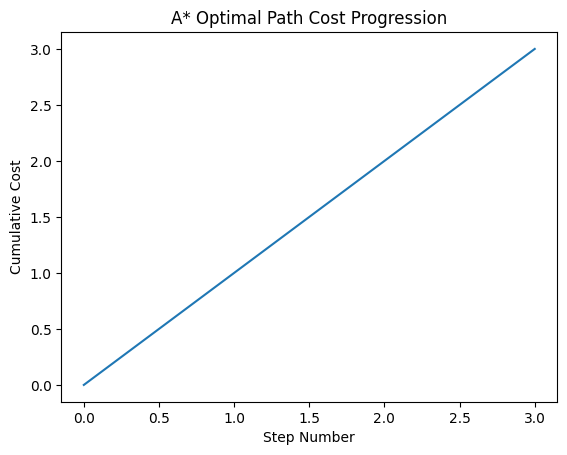

In [ ]:
# Calculate cumulative cost along final path
cost_progress = [0]
total = 0

for i in range(len(path) - 1):
    for neighbor, weight in graph[path[i]]:
        if neighbor == path[i+1]:
            total += weight
            cost_progress.append(total)

# Plot
plt.figure()
plt.plot(range(len(cost_progress)), cost_progress)
plt.xlabel("Step Number")
plt.ylabel("Cumulative Cost")
plt.title("A* Optimal Path Cost Progression")
plt.show()

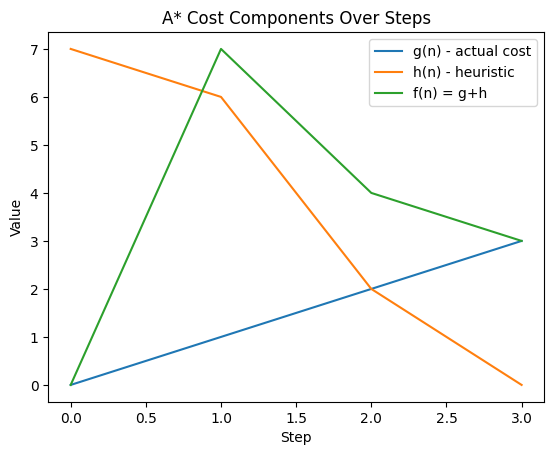

In [ ]:
g_vals = [s[1] for s in steps]
h_vals = [s[2] for s in steps]
f_vals = [s[3] for s in steps]

plt.figure()
plt.plot(g_vals, label="g(n) - actual cost")
plt.plot(h_vals, label="h(n) - heuristic")
plt.plot(f_vals, label="f(n) = g+h")
plt.xlabel("Step")
plt.ylabel("Value")
plt.title("A* Cost Components Over Steps")
plt.legend()
plt.show()

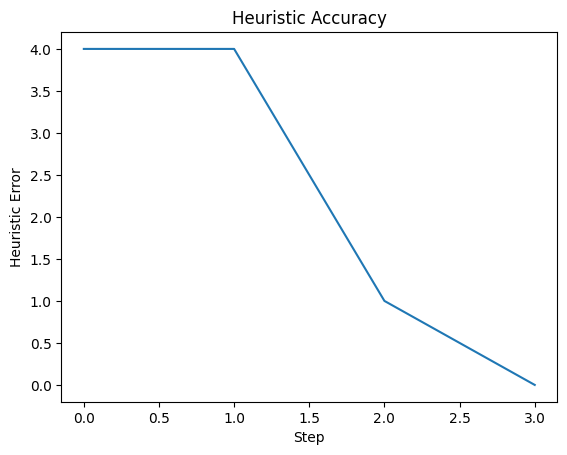

In [ ]:
diff = [abs(s[2] - (cost - s[1])) for s in steps]

plt.figure()
plt.plot(diff)
plt.xlabel("Step")
plt.ylabel("Heuristic Error")
plt.title("Heuristic Accuracy")
plt.show()